In [8]:
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *

## View topics distribution

In [9]:
from dataclasses import dataclass, field
from typing import Optional
import pandas as pd

@dataclass
class SubtopicStats:
    name: str
    count: int
    percentage: float  # percentage within parent topic

@dataclass
class TopicStats:
    name: str
    count: int
    percentage: float  # percentage of total posts
    subtopics: list[SubtopicStats] = field(default_factory=list)

@dataclass
class TopicsReport:
    total_posts: int
    total_topics: int
    total_unique_subtopics: int
    topics: list[TopicStats] = field(default_factory=list)

    def get_topic(self, name: str) -> Optional[TopicStats]:
        return next((t for t in self.topics if t.name == name), None)


def generate_topics_document(classified_path: str = VALIDATION_SAMPLE,
                             output_filename: str = 'topics_structure.txt') -> TopicsReport:

    df = pd.read_excel(classified_path)
    df = df[df['topic_veredict'] == True]
    df = df[df['subtopic_veredict'] == True]

    total_posts = len(df)
    topic_counts = df['topic'].value_counts()
    topic_percentages = (topic_counts / total_posts * 100).to_dict()
    sorted_topics = sorted(topic_percentages.items(), key=lambda x: x[1], reverse=True)

    report = TopicsReport(
        total_posts=total_posts,
        total_topics=len(sorted_topics),
        total_unique_subtopics=df['subtopics'].nunique()
    )

    lines = []
    lines.append("=" * 80)
    lines.append("TOPICS AND SUBTOPICS HIERARCHY")
    lines.append("=" * 80)
    lines.append("")

    for topic, topic_pct in sorted_topics:
        lines.append(f"{topic}: {topic_pct:.2f}% ({int(topic_counts[topic])} posts)")

        topic_posts = df[df['topic'] == topic]
        subtopic_counts = topic_posts['subtopics'].value_counts()
        subtopic_percentages = (subtopic_counts / len(topic_posts) * 100).to_dict()
        sorted_subtopics = sorted(subtopic_percentages.items(), key=lambda x: x[1], reverse=True)

        topic_stats = TopicStats(
            name=topic,
            count=int(topic_counts[topic]),
            percentage=topic_pct,
            subtopics=[
                SubtopicStats(
                    name=subtopic,
                    count=int(subtopic_counts[subtopic]),
                    percentage=subtopic_pct
                )
                for subtopic, subtopic_pct in sorted_subtopics
            ]
        )
        report.topics.append(topic_stats)

        for subtopic, subtopic_pct in sorted_subtopics:
            lines.append(f"  - {subtopic}: {subtopic_pct:.2f}% ({int(subtopic_counts[subtopic])} posts)")
        lines.append("")

    lines.append("")
    lines.append("=" * 80)
    lines.append("SUMMARY")
    lines.append("=" * 80)
    lines.append(f"Total posts: {report.total_posts}")
    lines.append(f"Total topics: {report.total_topics}")
    lines.append(f"Total unique subtopics: {report.total_unique_subtopics}")

    for l in lines:
        print(l)

    return report


report = generate_topics_document()

TOPICS AND SUBTOPICS HIERARCHY

OpenSSL installation/build and runtime errors: 14.15% (44 posts)
  - OpenSSL installation/build and linking (versions, packages, compilation): 81.82% (36 posts)
  - TLS/SSL runtime errors (certificates & connection issues): 11.36% (5 posts)
  - Key/certificate files and OpenSSL command usage: 6.82% (3 posts)

Encoding and byte/string conversions (Base64, binary): 11.90% (37 posts)
  - Byte/string/character encoding conversions (Base64, binary, hashes): 48.65% (18 posts)
  - Password hashing implementation and verification (MD5 and checks): 37.84% (14 posts)
  - Symmetric encryption/decryption errors (keys, padding, file/text decoding): 13.51% (5 posts)

X.509 certificates, signing, and trust chains: 8.36% (26 posts)
  - Private key & keystore management (PKCS#12, import/export/convert): 19.23% (5 posts)
  - Trust stores and certificate chain building/validation: 15.38% (4 posts)
  - Debugging certificate/crypto verification code errors: 15.38% (4 posts)


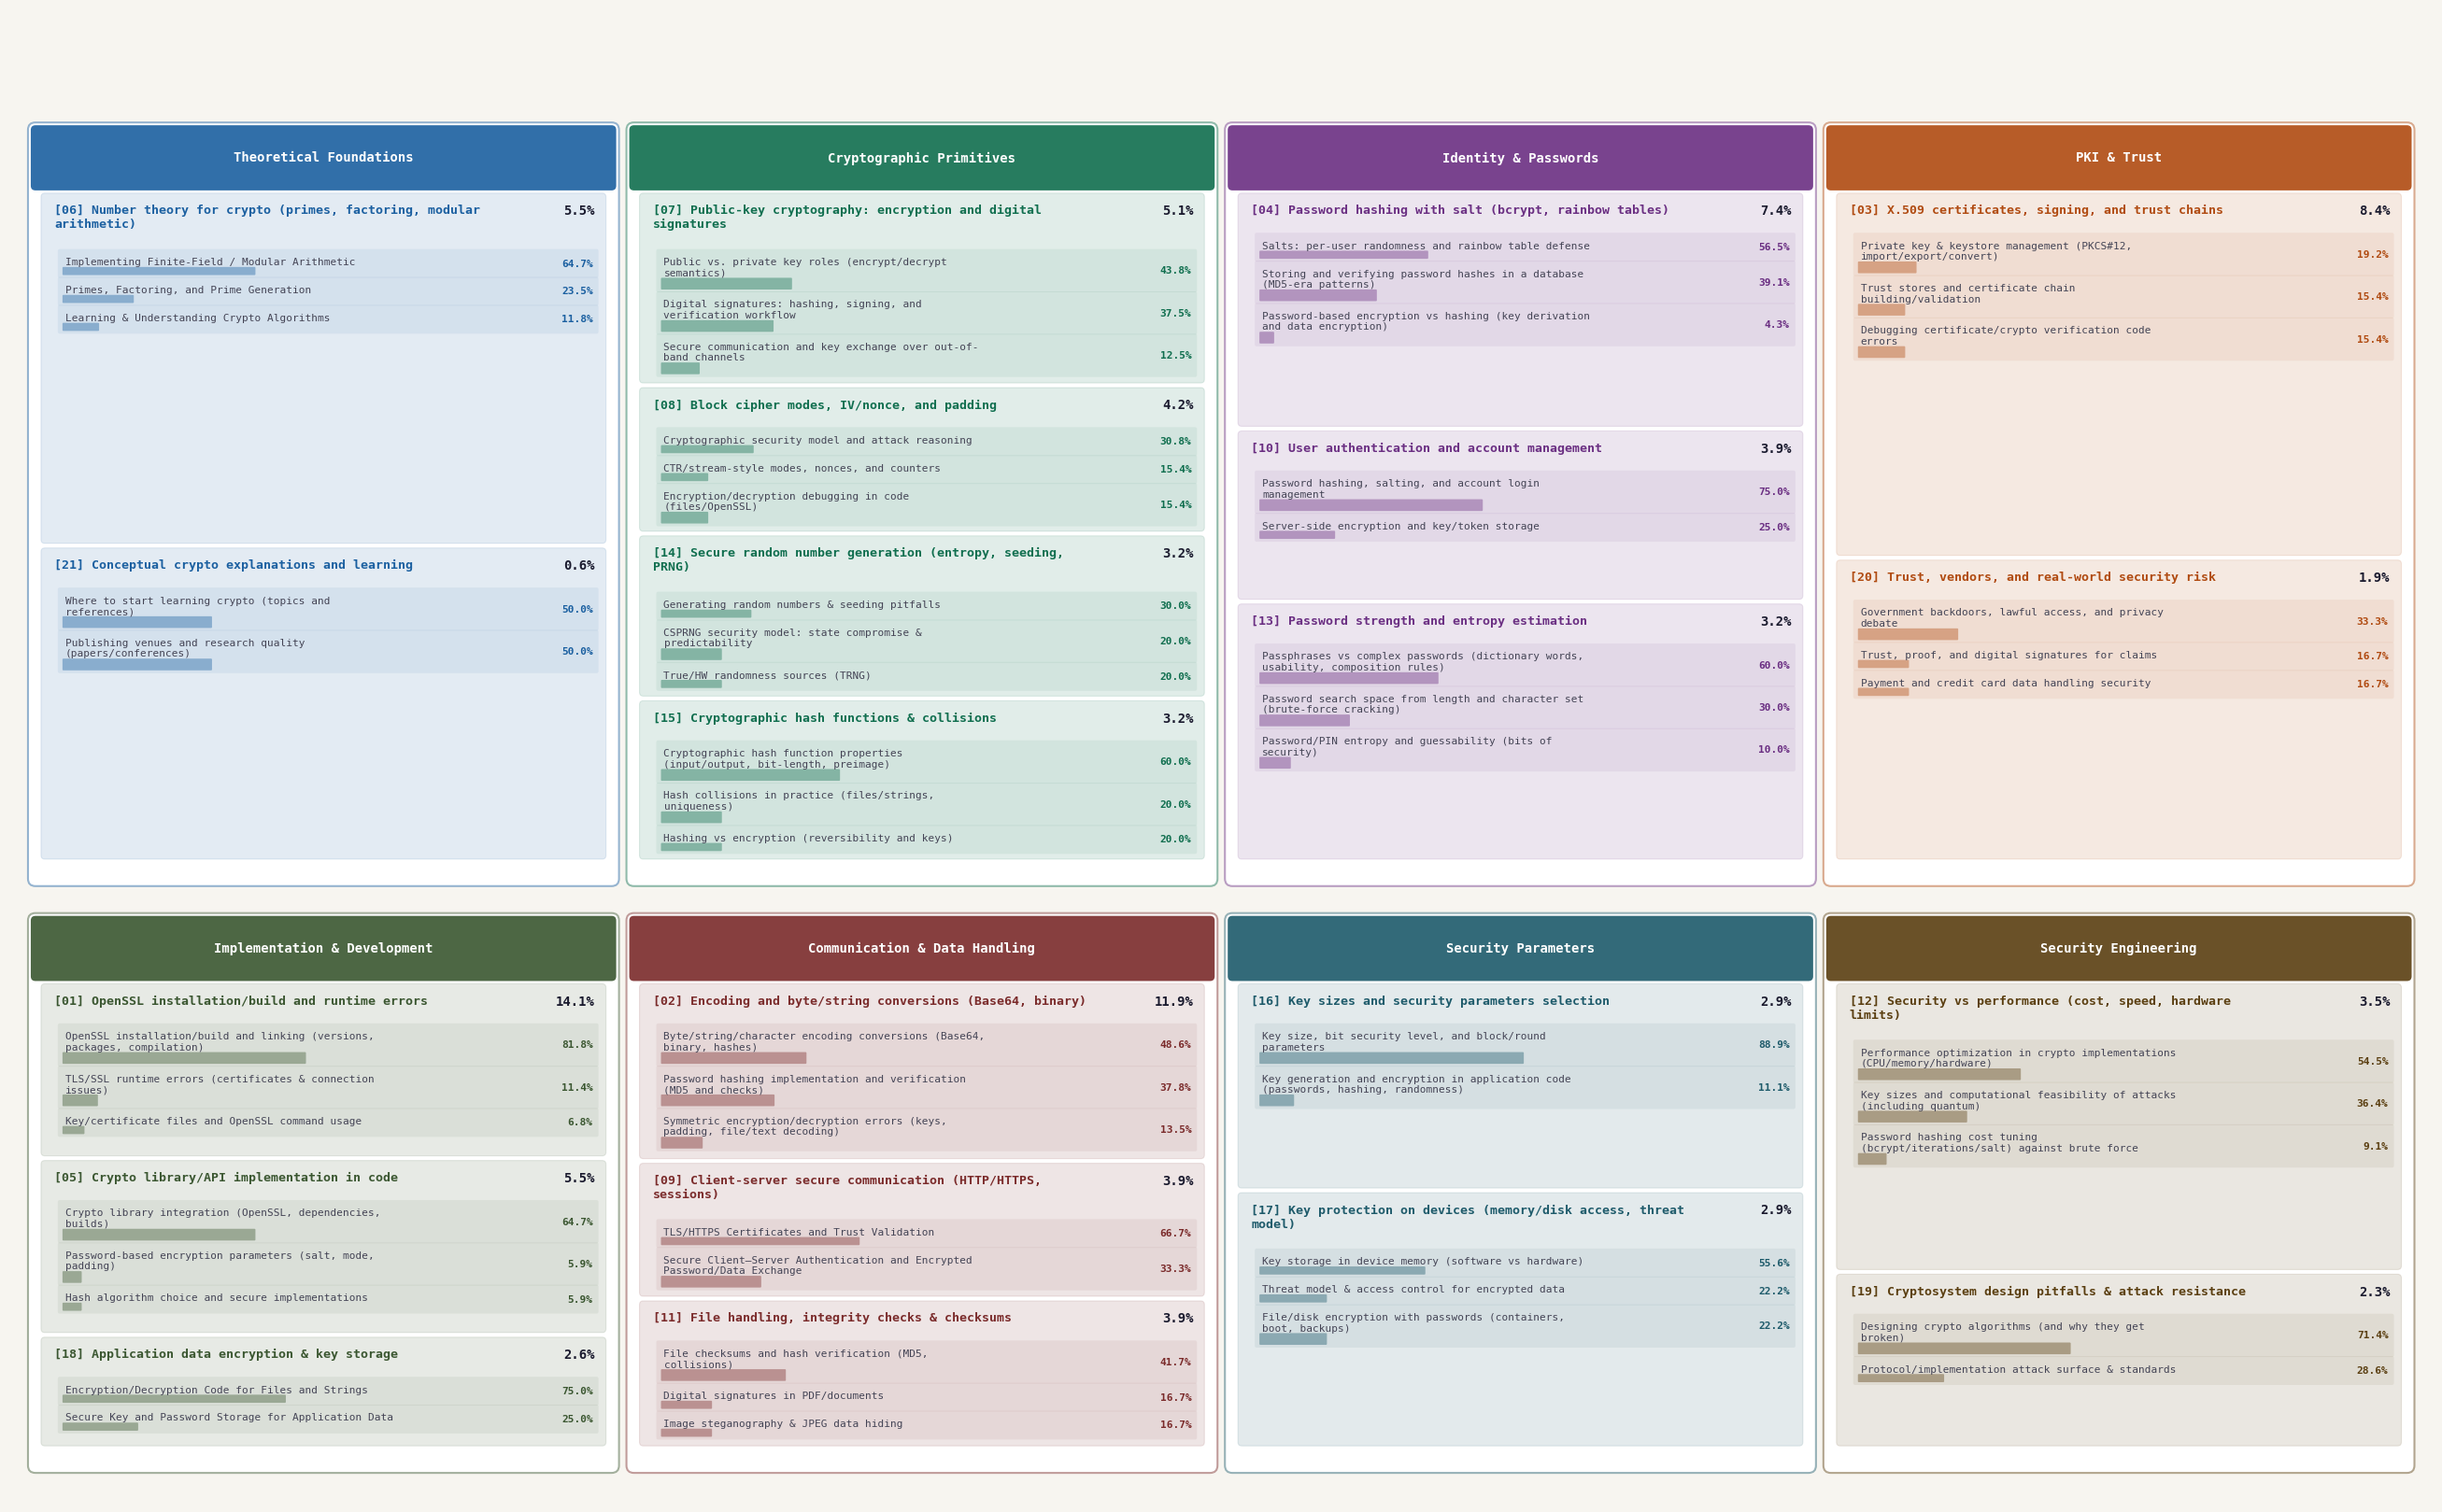

In [15]:
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import FancyBboxPatch
from dataclasses import dataclass, field
from typing import Optional

# ── Data classes ──────────────────────────────────────────────────────────────
@dataclass
class SubtopicStats:
    name: str
    count: int
    percentage: float

@dataclass
class TopicStats:
    name: str
    count: int
    percentage: float
    subtopics: list = field(default_factory=list)

@dataclass
class TopicsReport:
    total_posts: int
    total_topics: int
    total_unique_subtopics: int
    topics: list = field(default_factory=list)

    def get_topic(self, name: str) -> Optional[TopicStats]:
        return next((t for t in self.topics if t.name == name), None)

# ── Metadata ──────────────────────────────────────────────────────────────────
topic_names = {
    "01": "OpenSSL installation/build and runtime errors",
    "02": "Encoding and byte/string conversions (Base64, binary)",
    "03": "X.509 certificates, signing, and trust chains",
    "04": "Password hashing with salt (bcrypt, rainbow tables)",
    "05": "Crypto library/API implementation in code",
    "06": "Number theory for crypto (primes, factoring, modular arithmetic)",
    "07": "Public-key cryptography: encryption and digital signatures",
    "08": "Block cipher modes, IV/nonce, and padding",
    "09": "Client-server secure communication (HTTP/HTTPS, sessions)",
    "10": "User authentication and account management",
    "11": "File handling, integrity checks & checksums",
    "12": "Security vs performance (cost, speed, hardware limits)",
    "13": "Password strength and entropy estimation",
    "14": "Secure random number generation (entropy, seeding, PRNG)",
    "15": "Cryptographic hash functions & collisions",
    "16": "Key sizes and security parameters selection",
    "17": "Key protection on devices (memory/disk access, threat model)",
    "18": "Application data encryption & key storage",
    "19": "Cryptosystem design pitfalls & attack resistance",
    "20": "Trust, vendors, and real-world security risk",
    "21": "Conceptual crypto explanations and learning",
}

topics_per_group = {
    "Theoretical\nFoundations":      [6, 21],
    "Cryptographic\nPrimitives":     [7, 8, 14, 15],
    "Identity &\nPasswords":         [4, 10, 13],
    "PKI & Trust":                   [3, 20],
    "Implementation &\nDevelopment": [1, 5, 18],
    "Communication &\nData Handling":[2, 9, 11],
    "Security\nParameters":          [16, 17],
    "Security\nEngineering":         [12, 19],
}

GROUP_COLORS = [
    "#1A5FA0",
    "#0F6E4E",
    "#6A2E82",
    "#B04A10",
    "#3A5630",
    "#7A2A2A",
    "#1D5A6A",
    "#5A3E10",
]

MAX_SUBS    = 3
TOPIC_ALPHA = 0.12
SUB_ALPHA   = 0.07
BG_COLOR    = "#F7F5F0"
PANEL_BG    = "#FFFFFF"
TITLE_COLOR = "#1A1A2E"

# ── Layout constants ───────────────────────────────────────────────────────────
WRAP_W_TOPIC     = 58    # ← increased from 40
WRAP_W_SUB       = 52    # ← increased from 36
LINE_H_TOPIC     = 0.175
LINE_H_SUB       = 0.155
TOPIC_LABEL_BASE = 0.12   # vertical padding around topic label text
SUB_FIXED_H      = 0.30   # minimum height per subtopic row
SUB_TOP_PAD      = 0.08   # gap between topic label and first subtopic
TOPIC_GAP        = 0.13   # gap between consecutive topic boxes
HEADER_H         = 0.60
PANEL_PAD_TOP    = 0.12   # inside padding below header
PANEL_PAD_BOT    = 0.12   # inside padding at bottom of panel
PANEL_PAD_SIDE   = 0.10   # horizontal inset for topic boxes


def count_lines(text: str, width: int) -> int:
    lines = textwrap.wrap(text, width=width)
    return max(len(lines), 1)


def wrap_label(text: str, width: int) -> str:
    lines = textwrap.wrap(text, width=width)
    return "\n".join(lines) if lines else text


def measure_topic_h(ts: TopicStats) -> tuple[float, list[int]]:
    """Return (total box height, list of line-counts per subtopic)."""
    num_str = next((k for k, v in topic_names.items() if v == ts.name), "??")
    label   = f"[{num_str}] {ts.name}"
    n_topic = count_lines(label, WRAP_W_TOPIC)
    topic_label_h = TOPIC_LABEL_BASE + n_topic * LINE_H_TOPIC

    top_subs = sorted(ts.subtopics, key=lambda s: s.percentage, reverse=True)[:MAX_SUBS]
    sub_nls  = [count_lines(s.name, WRAP_W_SUB) for s in top_subs]
    subs_h   = sum(SUB_FIXED_H + max(0, nl - 1) * LINE_H_SUB for nl in sub_nls)

    total = topic_label_h + SUB_TOP_PAD + subs_h
    return total, sub_nls


def panel_content_height(topic_ids: list[int], id_to_stats: dict) -> float:
    """Total panel height needed (header + all topics + padding)."""
    topics = [id_to_stats[tid] for tid in topic_ids if tid in id_to_stats]
    if not topics:
        return HEADER_H + 1.0
    topics_h = sum(measure_topic_h(ts)[0] for ts in topics)
    gaps_h   = TOPIC_GAP * len(topics)   # gap after every topic (incl. last = bottom pad)
    return HEADER_H + PANEL_PAD_TOP + topics_h + gaps_h + PANEL_PAD_BOT


def build_figure(report: TopicsReport) -> plt.Figure:
    name_to_stats = {t.name: t for t in report.topics}
    id_to_stats: dict[int, TopicStats] = {}
    for num_str, full_name in topic_names.items():
        if full_name in name_to_stats:
            id_to_stats[int(num_str)] = name_to_stats[full_name]

    groups = list(topics_per_group.items())

    # ── Per-panel natural heights ─────────────────────────────────────────────
    all_heights = [panel_content_height(tids, id_to_stats) for _, tids in groups]
    top_heights = all_heights[:4]
    bot_heights = all_heights[4:]

    row0_h = max(top_heights) + 0.15    # uniform row height = tallest panel + small margin
    row1_h = max(bot_heights) + 0.15

    # ── Canvas ────────────────────────────────────────────────────────────────
    MARGIN_X  = 0.28
    MARGIN_Y  = 0.40
    GAP_X     = 0.24
    GAP_Y     = 0.45
    TITLE_BAR = 0.90
    N_COLS    = 4

    FIG_W = 26
    FIG_H = TITLE_BAR + row0_h + GAP_Y + row1_h + 2 * MARGIN_Y

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_xlim(0, FIG_W)
    ax.set_ylim(0, FIG_H)
    ax.axis("off")
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    usable_w = FIG_W - 2 * MARGIN_X
    col_w    = (usable_w - (N_COLS - 1) * GAP_X) / N_COLS

    y_row0 = MARGIN_Y + row1_h + GAP_Y   # bottom-left y of top row
    y_row1 = MARGIN_Y                    # bottom-left y of bottom row

    def panel_x(col: int) -> float:
        return MARGIN_X + col * (col_w + GAP_X)

    # ── Draw one group panel ──────────────────────────────────────────────────
    def draw_group(group_name, topic_ids, gx, gy, gw, gh, color):
        # ① Full white card — exactly gh tall, colour fills the whole area
        ax.add_patch(FancyBboxPatch(
            (gx, gy), gw, gh,
            boxstyle="round,pad=0.08",
            facecolor=PANEL_BG, edgecolor="none", alpha=1.0, zorder=1))

        # ② Coloured header bar at the TOP of the panel
        ax.add_patch(FancyBboxPatch(
            (gx, gy + gh - HEADER_H), gw, HEADER_H,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor="none", alpha=0.90, zorder=3))
        ax.text(gx + gw / 2, gy + gh - HEADER_H / 2,
                group_name.replace("\n", " "),
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white", fontfamily="monospace", zorder=4)

        # ③ Coloured border around the whole panel
        ax.add_patch(FancyBboxPatch(
            (gx, gy), gw, gh,
            boxstyle="round,pad=0.08",
            facecolor="none", edgecolor=color, linewidth=1.5, alpha=0.45, zorder=2))

        topics_in_group = [id_to_stats[tid] for tid in topic_ids if tid in id_to_stats]
        if not topics_in_group:
            return

        topic_layout = []
        for ts in topics_in_group:
            natural_h, sub_nls = measure_topic_h(ts)
            topic_layout.append({
                "ts": ts,
                "natural_h": natural_h,
                "sub_nls": sub_nls,
            })

        total_natural = sum(item["natural_h"] for item in topic_layout)
        available_h = gh - HEADER_H - PANEL_PAD_TOP - PANEL_PAD_BOT - TOPIC_GAP * len(topic_layout)
        scale = available_h / total_natural if total_natural > 0 else 1.0

        # cursor starts just below the header
        cursor_y = gy + gh - HEADER_H - PANEL_PAD_TOP

        for item in topic_layout:
            ts = item["ts"]
            num_str = next((k for k, v in topic_names.items() if v == ts.name), "??")
            label   = f"[{num_str}] {ts.name}"

            n_topic       = count_lines(label, WRAP_W_TOPIC)
            topic_label_h = TOPIC_LABEL_BASE + n_topic * LINE_H_TOPIC

            top_subs = sorted(ts.subtopics, key=lambda s: s.percentage, reverse=True)[:MAX_SUBS]
            sub_nls  = item["sub_nls"]
            subs_block_h = sum(SUB_FIXED_H + max(0, nl - 1) * LINE_H_SUB for nl in sub_nls)

            natural_th = topic_label_h + SUB_TOP_PAD + subs_block_h
            th = natural_th * scale
            ty = cursor_y - th
            tx = gx + PANEL_PAD_SIDE
            tw = gw - 2 * PANEL_PAD_SIDE

            # ④ Topic box (tinted background, full width inside panel)
            ax.add_patch(FancyBboxPatch(
                (tx, ty), tw, th,
                boxstyle="round,pad=0.04",
                facecolor=color, edgecolor=color,
                alpha=TOPIC_ALPHA, linewidth=0.8, zorder=3))

            # Topic label — top-left
            wrapped_topic = wrap_label(label, WRAP_W_TOPIC)
            ax.text(tx + 0.10, ty + th - 0.08,
                    wrapped_topic,
                    ha="left", va="top", multialignment="left",
                    fontsize=9.5, fontweight="bold",
                    color=color, fontfamily="monospace", zorder=4, clip_on=True)

            # Percentage — top-right
            ax.text(tx + tw - 0.08, ty + th - 0.08,
                    f"{ts.percentage:.1f}%",
                    ha="right", va="top", fontsize=10, fontweight="bold",
                    color=TITLE_COLOR, fontfamily="monospace", zorder=4)

            # Subtopics drawn downward from below the topic label
            sub_cursor_y = ty + th - topic_label_h - SUB_TOP_PAD

            for sub, nl in zip(top_subs, sub_nls):
                sub_h = SUB_FIXED_H + max(0, nl - 1) * LINE_H_SUB
                sy    = sub_cursor_y - sub_h
                sx    = tx + 0.16
                sw    = tw - 0.22

                # Subtopic tinted background
                ax.add_patch(FancyBboxPatch(
                    (sx, sy), sw, sub_h - 0.03,
                    boxstyle="round,pad=0.02",
                    facecolor=color, edgecolor="none",
                    alpha=SUB_ALPHA, zorder=4))

                # Proportional bar
                bar_w = max((sub.percentage / 100) * sw * 0.55, 0.02)
                ax.add_patch(FancyBboxPatch(
                    (sx + 0.04, sy + 0.02), bar_w, (sub_h - 0.03) * 0.25,
                    boxstyle="round,pad=0.01",
                    facecolor=color, edgecolor="none", alpha=0.40, zorder=5))

                # Subtopic label
                wrapped_sub = wrap_label(sub.name, WRAP_W_SUB)
                ax.text(sx + 0.06, sy + sub_h - 0.10,
                        wrapped_sub,
                        ha="left", va="top", multialignment="left",
                        fontsize=8.0, color="#444455",
                        fontfamily="monospace", zorder=6, clip_on=True)

                # Subtopic percentage
                ax.text(sx + sw - 0.04, sy + (sub_h - 0.03) / 2,
                        f"{sub.percentage:.1f}%",
                        ha="right", va="center", fontsize=8.0,
                        color=color, fontweight="bold",
                        fontfamily="monospace", zorder=6)

                sub_cursor_y = sy

            cursor_y = ty - TOPIC_GAP

    # ── Place panels in grid ───────────────────────────────────────────────────
    for col, (gname, tids) in enumerate(groups[:4]):
        draw_group(gname, tids, panel_x(col), y_row0, col_w, row0_h, GROUP_COLORS[col])

    for col, (gname, tids) in enumerate(groups[4:]):
        draw_group(gname, tids, panel_x(col), y_row1, col_w, row1_h, GROUP_COLORS[col + 4])

    plt.tight_layout(pad=0.2)
    return fig


# ── Usage ──────────────────────────────────────────────────────────────────────
fig = build_figure(report)
fig.savefig(NOTEBOOK_OUTPUTS / 'rq1' / 'plots'/"topics_hierarchy.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()